# Does `Graphics3d` display in a *plain* Python kernel?

This notebook is running on the stock **python3** (ipykernel) kernel — **not** the
`sagemath` kernel. That is the whole point: the Sage kernel installs
`SageDisplayFormatter`, which calls `_rich_repr_()` and would render 3d plots even
without this PR. A plain kernel (JupyterLite, Colab, marimo, VS Code) has only
stock IPython, which looks for `_repr_png_()`.

PR [#2698](https://github.com/passagemath/passagemath/pull/2698) adds
`Graphics3d._repr_png_()`. Run the cells and look at the pictures.

In [1]:
import sys, IPython
print("python  :", sys.executable)
print("ipython :", IPython.__version__)
fmt = get_ipython().display_formatter
print("formatter:", type(fmt).__module__ + "." + type(fmt).__name__)
assert type(fmt).__name__ == "DisplayFormatter", "this is a Sage kernel - switch to python3!"
print("\n-> stock IPython DisplayFormatter. No Sage rich-output system in play.")

python  : ~/foundry/sandbox/passagemath/.venv-plot3d/bin/python
ipython : 9.17.0
formatter: IPython.core.formatters.DisplayFormatter

-> stock IPython DisplayFormatter. No Sage rich-output system in play.


## The 3d objects

Each of these returns a `Graphics3d`. Before the PR, every one of them printed
`Graphics3d Object` as text. Rendering goes through **tachyon** (a raytracer that
ships as a wheel), not through a headless browser — no Three.js, no playwright.

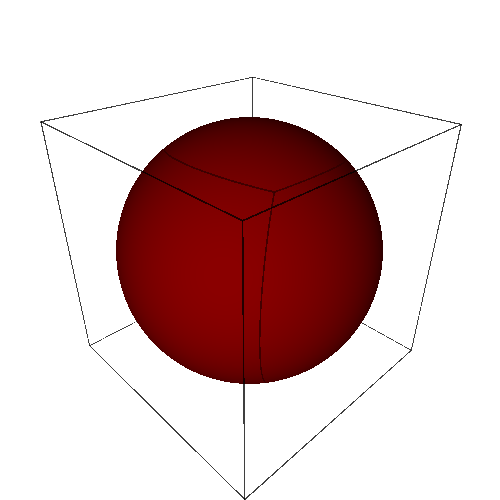

In [2]:
from sage.all__sagemath_symbolics import *
from sage.all__sagemath_plot import *
x, y, z = var('x y z')
sphere(color='darkred')

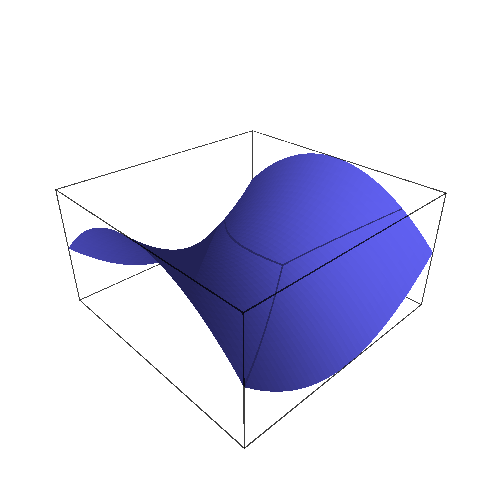

In [3]:
plot3d(x**2 - y**2, (x, -2, 2), (y, -2, 2))

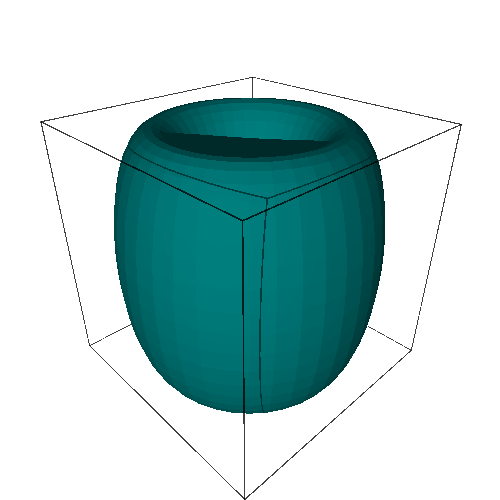

In [4]:
parametric_plot3d([(2+cos(x))*cos(y), (2+cos(x))*sin(y), sin(x)],
                  (x, 0, 2*pi), (y, 0, 2*pi), color='teal')

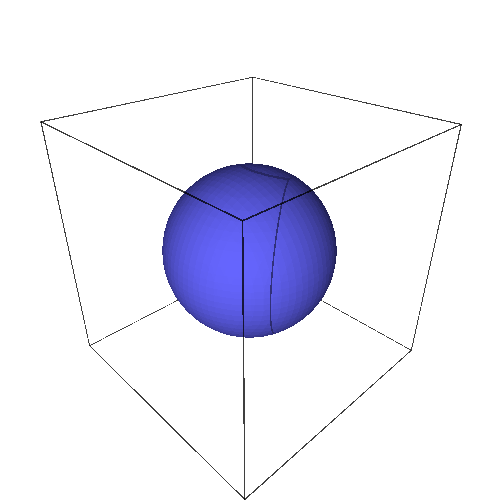

In [5]:
implicit_plot3d(x**2 + y**2 + z**2 - 4, (x,-3,3), (y,-3,3), (z,-3,3))

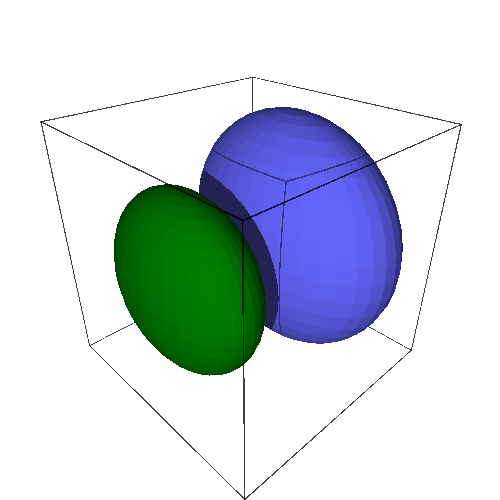

In [6]:
# a composite object (Graphics3dGroup) - the sum of two plots
sphere((0,0,0), 1) + sphere((2,0,0), 0.7, color='green')

## The showpiece

A **gyroid** — the triply periodic minimal surface, a level set of
$\cos x \sin y + \cos y \sin z + \cos z \sin x = 0$ — shaded by a viridis colormap.

This is the real test, not `sphere()`. It is an 80×80×80 marching-cubes mesh with a
per-face texture, and the PNG that comes back is ~120 KB. If `_repr_png_()` were
mishandling the colormap path or choking on mesh size, this is where it would show.
Tachyon raytraces it in about two seconds.

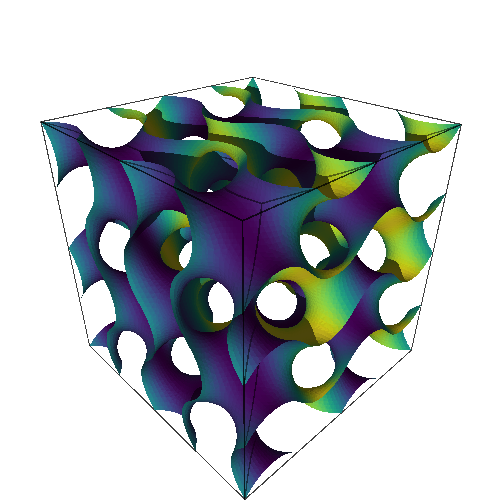

In [7]:
implicit_plot3d(cos(x)*sin(y) + cos(y)*sin(z) + cos(z)*sin(x) == 0,
                (x, -2*pi, 2*pi), (y, -2*pi, 2*pi), (z, -2*pi, 2*pi),
                plot_points=80,
                color=(lambda a, b, c: (sin(a) + 1)/2, colormaps.viridis))

And a **Chmutov surface**, $T_8(x) + T_8(y) + T_8(z) = 0$ with $T_n$ the Chebyshev
polynomials — a degree-8 algebraic surface that comes out as a dimpled cube.

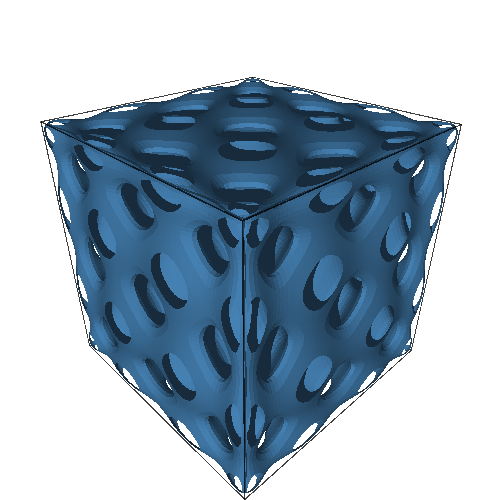

In [8]:
implicit_plot3d(chebyshev_T(8,x) + chebyshev_T(8,y) + chebyshev_T(8,z) == 0,
                (x, -1, 1), (y, -1, 1), (z, -1, 1),
                plot_points=70, color='steelblue')

---

# Gallery

Six harder cases. Each one leans on a different part of the render path, so if
`_repr_png_()` were fragile in some particular way, one of these would expose it.

In [9]:
import math
u, v, th, ph = var('u v th ph')

### Boy's surface

An immersion of the real projective plane in 3-space, in the Apéry parametrization.
Self-intersecting, so the raytracer has to cope with a surface that passes through
itself — colored by the `turbo` colormap.

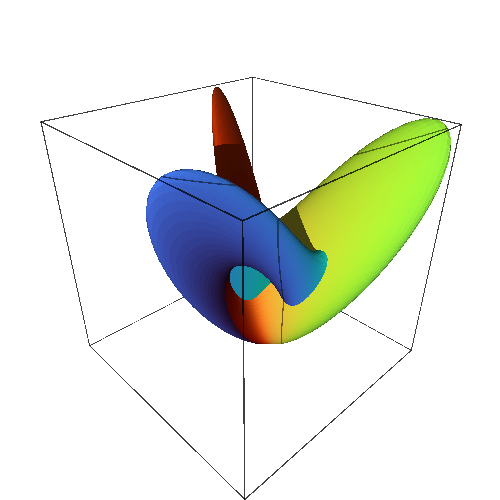

In [10]:
X = (sqrt(2)*cos(2*u)*cos(v)**2 + cos(u)*sin(2*v))/(2 - sqrt(2)*sin(3*u)*sin(2*v))
Y = (sqrt(2)*sin(2*u)*cos(v)**2 - sin(u)*sin(2*v))/(2 - sqrt(2)*sin(3*u)*sin(2*v))
Z = 3*cos(v)**2/(2 - sqrt(2)*sin(3*u)*sin(2*v))
parametric_plot3d([X, Y, Z], (u, 0, pi), (v, 0, pi), plot_points=[130, 130],
                  color=(lambda a, b: a/float(pi), colormaps.turbo))

### Dini's surface

A surface of constant negative curvature — a helicoid twisted around a pseudosphere.
The parametrization runs to $4\pi$, so it wraps twice; note the `log(tan(v/2))`
singularity as $v \to 0$, which is why the domain starts at $0.05$.

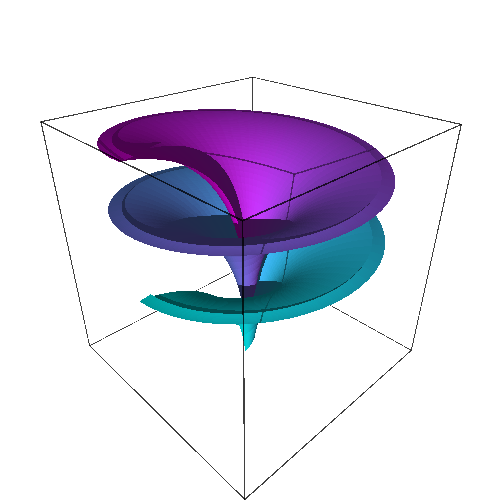

In [11]:
dini = (cos(u)*sin(v), sin(u)*sin(v), cos(v) + log(tan(v/2)) + 0.2*u)
parametric_plot3d(dini, (u, 0, 4*pi), (v, 0.05, 2), plot_points=[120, 60],
                  color=(lambda a, b: a/(4*float(pi)), colormaps.cool))

### The Clebsch diagonal cubic

The smooth cubic surface containing exactly 27 real lines — the classical one.
A degree-3 implicit surface at `plot_points=90`.

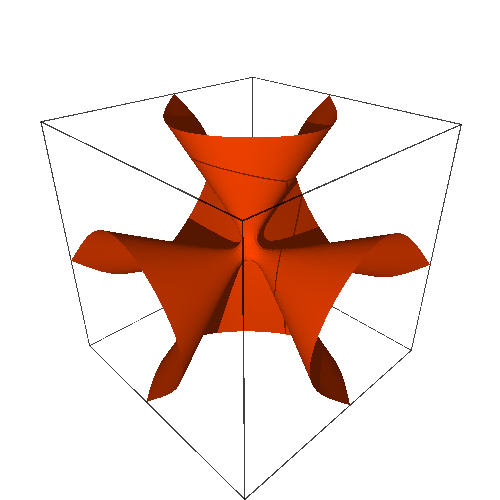

In [12]:
clebsch = (81*(x**3 + y**3 + z**3)
           - 189*(x**2*y + x**2*z + y**2*x + y**2*z + z**2*x + z**2*y)
           + 54*x*y*z + 126*(x*y + x*z + y*z)
           - 9*(x**2 + y**2 + z**2) - 9*(x + y + z) + 1)
implicit_plot3d(clebsch == 0, (x, -3, 3), (y, -3, 3), (z, -3, 3),
                plot_points=90, color='orangered')

### A spherical harmonic

Plotted in spherical coordinates rather than Cartesian — a different mesh generator
(`spherical_plot3d`) feeding the same display path. Twelve lobes, shaded by `magma`.

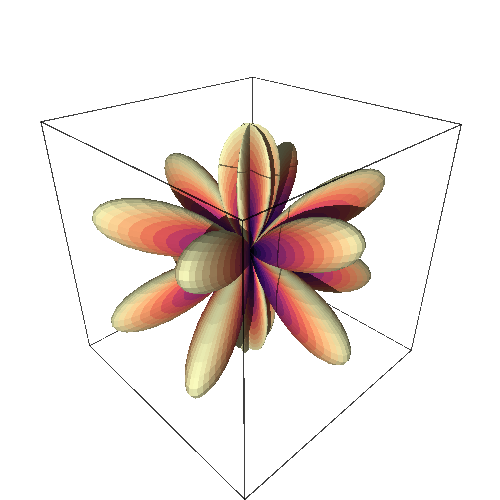

In [13]:
spherical_plot3d(abs(sin(3*th)**2 * cos(3*ph)), (th, 0, pi), (ph, 0, 2*pi),
                 plot_points=[120, 120],
                 color=(lambda a, b: float(sin(3*a)**2), colormaps.magma))

### A (3, 8) torus knot

Not a surface at all — a `line3d` with a `radius`, which builds a tube around a
space curve. 2000 points of curve, so a long thin mesh rather than a blobby one.

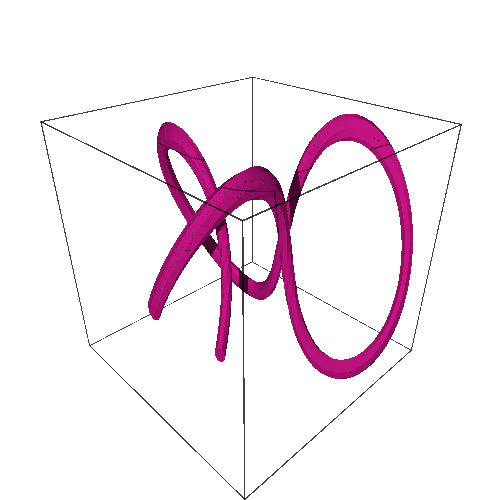

In [14]:
pts = [((2 + math.cos(8*s/3))*math.cos(s),
        (2 + math.cos(8*s/3))*math.sin(s),
        math.sin(8*s/3))
       for s in [2*math.pi*i/2000 for i in range(2001)]]
line3d(pts, radius=0.12, color='mediumvioletred')

### The Hopf fibration

The real stress test: **48 separate tubes** summed into one `Graphics3dGroup`.

Each circle is a fiber of the Hopf map $S^3 \to S^2$ — the preimage of a single
point on the sphere — stereographically projected into $\mathbb{R}^3$. Any two of
them are linked exactly once. Fibers are colored by the latitude of the point they
sit over, and clipped to a box since fibers near the projection pole run off to
infinity.

48 fibers in one Graphics3dGroup


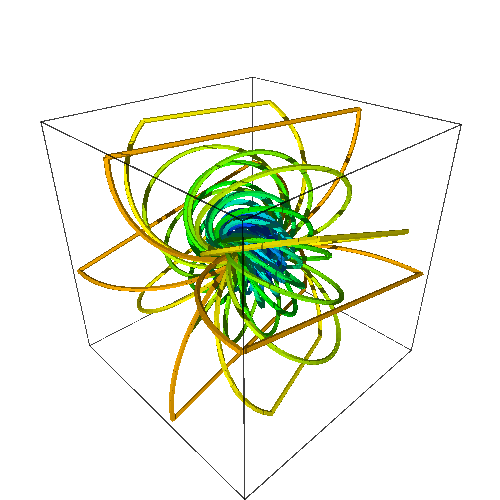

In [15]:
def hopf_fiber(a, phi, radius=0.09):
    px, py, pz = math.sin(a)*math.cos(phi), math.sin(a)*math.sin(phi), math.cos(a)
    n, pts = math.sqrt(2*(1 + pz)), []
    for i in range(241):
        s = 2*math.pi*i/240
        q = ((1 + pz)*math.cos(s)/n, (px*math.sin(s) - py*math.cos(s))/n,
             (px*math.cos(s) + py*math.sin(s))/n, (1 + pz)*math.sin(s)/n)
        d = 1 - q[3]
        if abs(d) < 1e-3:
            d = 1e-3
        p = (q[0]/d, q[1]/d, q[2]/d)
        if max(abs(c) for c in p) < 5:          # clip: fibers near the pole escape
            pts.append(p)
    return line3d(pts, radius=radius, color=hue(0.8*a/math.pi)) if len(pts) > 30 else None

fibers = [f for k in range(12) for j in range(4)
          for f in [hopf_fiber(0.45 + (math.pi - 1.2)*k/11.0, 2*math.pi*j/4 + k*0.5)]
          if f is not None]
print("%d fibers in one Graphics3dGroup" % len(fibers))
sum(fibers[1:], fibers[0])

## What actually came back

The output above is a PNG, and *only* a PNG — no `text/html` blob smuggling a
Three.js scene into the notebook file. Check it directly:

In [16]:
from IPython.core.formatters import DisplayFormatter
data, meta = DisplayFormatter().format(sphere())
print("mime types:", sorted(data))

png = data['image/png']
if isinstance(png, str):
    import base64; png = base64.b64decode(png)
print("PNG magic :", png[:8] == b'\x89PNG\r\n\x1a\n')
print("bytes     :", len(png))
print("text/html present:", 'text/html' in data)

mime types: ['image/png', 'text/plain']
PNG magic : True
bytes     : 30660
text/html present: False


## 2d, for comparison

`Graphics._repr_png_()` (the 2d case, issue #2236) is the sibling change. Note the
2d object also offers SVG; the 3d ones are PNG-only.

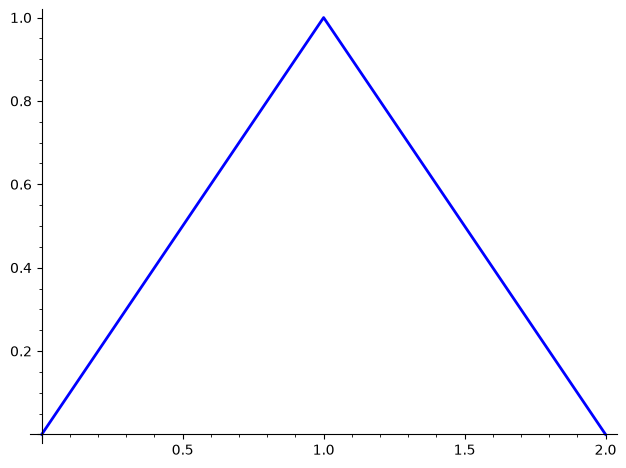

In [17]:
line([(0,0), (1,1), (2,0)], thickness=2)

In [18]:
print(sorted(DisplayFormatter().format(line([(0,0),(1,1)]))[0]))

['image/png', 'image/svg+xml', 'text/plain']


## The fallback, when tachyon isn't installed

`_repr_png_()` returns `None` rather than raising, so IPython quietly falls back to
`text/plain`. You can't see that from this venv — tachyon *is* installed here — but
the other venv proves it:

```bash
cd ~/foundry/sandbox/passagemath
.venv-plot3d-notachyon/bin/python \
    ~/foundry/sandbox/passagemath-workspace/kit/plot3d-repr/verify_notachyon.py
```

```
ok  : tachyon present = False
ok  : mime types = ['text/plain']
ok  : _repr_png_() returned None
PASS
```